<a href="https://colab.research.google.com/github/satnaam005/ai-inspection-readiness-portfolio/blob/main/Biotecnikaproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install chembl_webresource_client pandas

from chembl_webresource_client.new_client import new_client
import pandas as pd

# Step 1: Select target (EGFR kinase)
target = new_client.target
target_query = target.search('EGFR')
targets = pd.DataFrame.from_dict(target_query)

target_chembl_id = targets.iloc[0]['target_chembl_id']
print("Target ChEMBL ID:", target_chembl_id)

# Step 2: Fetch bioactivity data
activity = new_client.activity
res = activity.filter(target_chembl_id=target_chembl_id).filter(standard_type="IC50")

df = pd.DataFrame.from_dict(res)

# Step 3: Keep only required columns
df = df[['canonical_smiles', 'standard_value', 'standard_units']]

# Step 4: Clean basic missing values
df = df.dropna()

# Rename columns
df.columns = ['SMILES', 'IC50', 'Units']

# Save dataset
df.to_csv('chembl_egfr_ic50.csv', index=False)

df.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.3 MB/s eta 0:00:00
Target ChEMBL ID: CHEMBL3608


,SMILES,IC50,Units
0,COc1cccc2c(C(=O)Nc3ccccc3)c(SSc3c(C(=O)Nc4cccc...,100000.0,nM
1,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3ccccc3n2C)c(C(=O)N...,100000.0,nM
2,CN1C(=S)C(C(=O)Nc2ccccc2)c2ccccc21,100000.0,nM
3,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3cccnc3n2C)c(C(=O)N...,25000.0,nM
4,C/N=N/Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,70.0,nM


In [ ]:
# Save file
df.to_csv('chembl_egfr_ic50.csv', index=False)

# Download to your laptop
from google.colab import files
files.download('chembl_egfr_ic50.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

df = pd.read_csv('chembl_egfr_ic50.csv')
df.head()

,SMILES,IC50,Units
0,COc1cccc2c(C(=O)Nc3ccccc3)c(SSc3c(C(=O)Nc4cccc...,100000.0,nM
1,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3ccccc3n2C)c(C(=O)N...,100000.0,nM
2,CN1C(=S)C(C(=O)Nc2ccccc2)c2ccccc21,100000.0,nM
3,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3cccnc3n2C)c(C(=O)N...,25000.0,nM
4,C/N=N/Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,70.0,nM


In [ ]:
#Bioactivity data were filtered to retain only molar concentration units (nM, µM, mM). Entries reported in mass-based units (e.g., µg/mL) were excluded due to the lack of consistent molecular weight information required for conversion.

# Remove duplicates
df = df.drop_duplicates()

# Remove zero or negative IC50 values
df = df[df['IC50'] > 0]

# Keep only nM values (important consistency step)
df = df[df['Units'] == 'nM']

df.shape

(83, 3)

In [ ]:
import numpy as np

# Convert nM → M
df['IC50_M'] = df['IC50'] * 1e-9

# Calculate pIC50
df['pIC50'] = -np.log10(df['IC50_M'])

df[['IC50', 'pIC50']].head()

,IC50,pIC50
0,100000.0,4.000000
1,100000.0,4.000000
2,100000.0,4.000000
3,25000.0,4.602060
4,70.0,7.154902


In [ ]:
# Keep only required columns
df_final = df[['SMILES', 'pIC50']]

# Drop any remaining missing values
df_final = df_final.dropna()

df_final.shape

(83, 2)

In [ ]:
df_final.to_csv('clean_egfr_dataset.csv', index=False)

In [ ]:
from google.colab import files
files.download('clean_egfr_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ==============================
# 1. Install dependencies
# ==============================
!pip install chembl_webresource_client rdkit pandas numpy scikit-learn

# ==============================
# 2. Import libraries
# ==============================
from chembl_webresource_client.new_client import new_client
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Descriptors

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# ==============================
# 3. Fetch dataset from ChEMBL
# ==============================
print("Fetching target data...")
target = new_client.target
target_query = target.search('EGFR')
targets = pd.DataFrame.from_dict(target_query)

# Note: The first result is usually Human EGFR (CHEMBL203)
target_id = targets.iloc[0]['target_chembl_id']
print(f"Target selected: {target_id}")

print("Fetching bioactivity data (this may take a moment)...")
activity = new_client.activity
res = activity.filter(target_chembl_id=target_id).filter(standard_type="IC50")

df = pd.DataFrame.from_dict(res)

# ==============================
# 4. Select required columns
# ==============================
df = df[['canonical_smiles', 'standard_value', 'standard_units']]
df.columns = ['SMILES', 'IC50', 'Units']

# ==============================
# 5. Basic cleaning & Type Casting
# ==============================
df = df.dropna()

# FIX: Convert IC50 from string to float before math operations
df['IC50'] = df['IC50'].astype(float)
df = df[df['IC50'] > 0]

# Keep only molar units
df = df[df['Units'].isin(['nM', 'uM', 'mM', 'µM'])] # Added µM just in case ChEMBL uses the symbol

# ==============================
# 6. Convert all to nM
# ==============================
def convert_to_nM(row):
    if row['Units'] == 'nM':
        return row['IC50']
    elif row['Units'] in ['uM', 'µM']:
        return row['IC50'] * 1000
    elif row['Units'] == 'mM':
        return row['IC50'] * 1e6

df['IC50_nM'] = df.apply(convert_to_nM, axis=1)

# ==============================
# 7. Convert to pIC50
# ==============================
df['IC50_M'] = df['IC50_nM'] * 1e-9
df['pIC50'] = -np.log10(df['IC50_M'])

df = df[['SMILES', 'pIC50']].dropna()

# FIX: Reset the index to prevent misalignment during concatenation later
df = df.reset_index(drop=True)

print(f"Final dataset size before descriptors: {df.shape}")

# ==============================
# 8. Generate RDKit descriptors
# ==============================
def calculate_descriptors(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return {
                'MolWt': Descriptors.MolWt(mol),
                'LogP': Descriptors.MolLogP(mol),
                'NumHDonors': Descriptors.NumHDonors(mol),
                'NumHAcceptors': Descriptors.NumHAcceptors(mol)
            }
    except:
        pass
    return {'MolWt': None, 'LogP': None, 'NumHDonors': None, 'NumHAcceptors': None}

print("Calculating molecular descriptors...")
desc_list = df['SMILES'].apply(calculate_descriptors)
desc_df = pd.DataFrame(desc_list.tolist())

# Combine using the cleanly reset index
final_df = pd.concat([df, desc_df], axis=1).dropna()

print(f"After descriptor generation: {final_df.shape}")

# ==============================
# 9. Prepare ML data
# ==============================
X = final_df[['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors']]
y = final_df['pIC50']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==============================
# 10. Train model
# ==============================
print("Training Random Forest model...")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ==============================
# 11. Evaluate model
# ==============================
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n--- MODEL RESULTS ---")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE:     {rmse:.4f}")
print("---------------------\n")

# ==============================
# 12. Save final dataset
# ==============================
final_df.to_csv('final_ml_dataset.csv', index=False)

from google.colab import files
files.download('final_ml_dataset.csv')
print("Download initiated.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.8 MB/s eta 0:00:00
Fetching target data...
Target selected: CHEMBL3608
Fetching bioactivity data (this may take a moment)...
Final dataset size before descriptors: (83, 2)
Calculating molecular descriptors...
After descriptor generation: (83, 6)
Training Random Forest model...

--- MODEL RESULTS ---
R2 Score: -0.1494
RMSE:     0.9091
---------------------



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download initiated.


In [2]:
# ==============================
# 14. Add Morgan Fingerprints & Retrain
# ==============================
from rdkit.Chem import AllChem
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

print("Generating Morgan Fingerprints (this may take a minute)...")

# Function to calculate Morgan Fingerprints
def generate_morgan_fingerprints(smiles, radius=2, nBits=2048):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            # Generate the fingerprint as a bit vector
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
            return np.array(fp)
    except:
        pass
    # Return an array of zeros if conversion fails
    return np.zeros((nBits,))

# Apply the function to our SMILES column
fp_list = final_df['SMILES'].apply(generate_morgan_fingerprints)

# Convert the list of arrays into a DataFrame
fp_df = pd.DataFrame(fp_list.tolist(), index=final_df.index)

# Rename columns to keep things organized (Bit_0, Bit_1, ..., Bit_2047)
fp_df.columns = [f'Bit_{i}' for i in range(2048)]

# Combine our old descriptors with the new fingerprints
print("Merging structural features with dataset...")
X_new = pd.concat([final_df[['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors']], fp_df], axis=1)
y = final_df['pIC50']

# Train/Test Split on the new dataset
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

# Retrain the Model (n_jobs=-1 uses all CPU cores to speed it up)
print("Training upgraded Random Forest model...")
model_rf_fp = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf_fp.fit(X_train, y_train)

# Evaluate the new model
y_pred_new = model_rf_fp.predict(X_test)

r2_new = r2_score(y_test, y_pred_new)
rmse_new = np.sqrt(mean_squared_error(y_test, y_pred_new))

print("\n--- UPGRADED MODEL RESULTS ---")
print(f"Old R2:   -0.1494  | New R2:   {r2_new:.4f}")
print(f"Old RMSE:  0.9091  | New RMSE: {rmse_new:.4f}")
print("------------------------------\n")

Generating Morgan Fingerprints (this may take a minute)...


[02:15:04] DEPRECATION WARNING: please use MorganGenerator
[02:15:04] DEPRECATION WARNING: please use MorganGenerator
[02:15:04] DEPRECATION WARNING: please use MorganGenerator
[02:15:05] DEPRECATION WARNING: please use MorganGenerator
[02:15:05] DEPRECATION WARNING: please use MorganGenerator
[02:15:05] DEPRECATION WARNING: please use MorganGenerator
[02:15:05] DEPRECATION WARNING: please use MorganGenerator
[02:15:05] DEPRECATION WARNING: please use MorganGenerator
[02:15:05] DEPRECATION WARNING: please use MorganGenerator
[02:15:05] DEPRECATION WARNING: please use MorganGenerator
[02:15:05] DEPRECATION WARNING: please use MorganGenerator
[02:15:05] DEPRECATION WARNING: please use MorganGenerator
[02:15:05] DEPRECATION WARNING: please use MorganGenerator
[02:15:05] DEPRECATION WARNING: please use MorganGenerator
[02:15:05] DEPRECATION WARNING: please use MorganGenerator
[02:15:05] DEPRECATION WARNING: please use MorganGenerator
[02:15:05] DEPRECATION WARNING: please use MorganGenerat

Merging structural features with dataset...
Training upgraded Random Forest model...

--- UPGRADED MODEL RESULTS ---
Old R2:   -0.1494  | New R2:   0.2382
Old RMSE:  0.9091  | New RMSE: 0.7401
------------------------------



Part 1: The "Save State" Code Block

In [4]:
# ==============================
# 13. Persistent Storage (Save State)
# ==============================
from google.colab import drive
import joblib
import os

# 1. Mount Google Drive (You will be prompted to click allow)
print("Mounting Google Drive...")
drive.mount('/content/drive')

# 2. Create the project folder structure automatically
project_dir = '/content/drive/MyDrive/AI_Anticancer_Project'
data_dir = f'{project_dir}/data/processed'
model_dir = f'{project_dir}/models'

os.makedirs(data_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

# 3. Save the final ML dataset
dataset_path = f'{data_dir}/final_ml_dataset.csv'
final_df.to_csv(dataset_path, index=False)
print(f"✅ Dataset permanently saved to: {dataset_path}")

# 4. Save the trained Random Forest model
model_path = f'{model_dir}/rf_baseline_model.pkl'
joblib.dump(model, model_path)
print(f"✅ Model permanently saved to: {model_path}")

Mounting Google Drive...
Mounted at /content/drive
✅ Dataset permanently saved to: /content/drive/MyDrive/AI_Anticancer_Project/data/processed/final_ml_dataset.csv
✅ Model permanently saved to: /content/drive/MyDrive/AI_Anticancer_Project/models/rf_baseline_model.pkl


Part 2: The "Resume Work" Code Block

In [ ]:
# ==============================
# RESUME SESSION: Load Saved Data & Model
# ==============================
from google.colab import drive
import pandas as pd
import joblib

# 1. Mount Google Drive
drive.mount('/content/drive')

project_dir = '/content/drive/MyDrive/AI_Anticancer_Project'

# 2. Load the dataset
dataset_path = f'{project_dir}/data/processed/final_ml_dataset.csv'
final_df = pd.read_csv(dataset_path)
print(f"✅ Dataset loaded! Shape: {final_df.shape}")

# 3. Load the model
model_path = f'{project_dir}/models/rf_baseline_model.pkl'
loaded_model = joblib.load(model_path)
print("✅ Model loaded successfully!")

# You can now immediately use loaded_model to make new predictions!

In [5]:
# ==============================
# 15. Feature Selection & Model Tuning
# ==============================
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

print("Step 1: Removing low-variance (noisy) features...")
print(f"Original feature count: {X_train.shape[1]}")

# Drop features where 99% of the values are exactly the same
selector = VarianceThreshold(threshold=0.01)
X_train_clean = selector.fit_transform(X_train)
X_test_clean = selector.transform(X_test)

print(f"Cleaned feature count:  {X_train_clean.shape[1]}")

print("\nStep 2: Hunting for the best model parameters (this takes 1-3 minutes)...")

# Define the "grid" of parameters we want to test
param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0] # 1.0 is standard for modern scikit-learn
}

# Set up the Random Forest
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# Set up the Randomized Search (tests 15 random combinations, 3 times each)
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions,
    n_iter=15,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit the search to our cleaned data
random_search.fit(X_train_clean, y_train)

# Extract the best model
best_rf_model = random_search.best_estimator_

# Evaluate the tuned model
y_pred_tuned = best_rf_model.predict(X_test_clean)

r2_tuned = r2_score(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print("\n--- TUNED MODEL RESULTS ---")
print(f"Tuned R2:   {r2_tuned:.4f}")
print(f"Tuned RMSE: {rmse_tuned:.4f}")
print("---------------------------")
print(f"Best Parameters Found: {random_search.best_params_}")

# ==============================
# 16. Save the Upgraded Model
# ==============================
import joblib
# Make sure your Google Drive is still mounted from earlier!
model_path = '/content/drive/MyDrive/AI_Anticancer_Project/models/rf_tuned_model.pkl'
joblib.dump(best_rf_model, model_path)

# Save the variance selector too, so we can clean future novel compounds exactly the same way
selector_path = '/content/drive/MyDrive/AI_Anticancer_Project/models/feature_selector.pkl'
joblib.dump(selector, selector_path)

print(f"\n✅ Upgraded model and feature selector saved to Drive!")

Step 1: Removing low-variance (noisy) features...
Original feature count: 2052
Cleaned feature count:  605

Step 2: Hunting for the best model parameters (this takes 1-3 minutes)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

--- TUNED MODEL RESULTS ---
Tuned R2:   0.5178
Tuned RMSE: 0.5888
---------------------------
Best Parameters Found: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}

✅ Upgraded model and feature selector saved to Drive!


Extracting AI decision logic...


/tmp/ipykernel_2215/2808378622.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


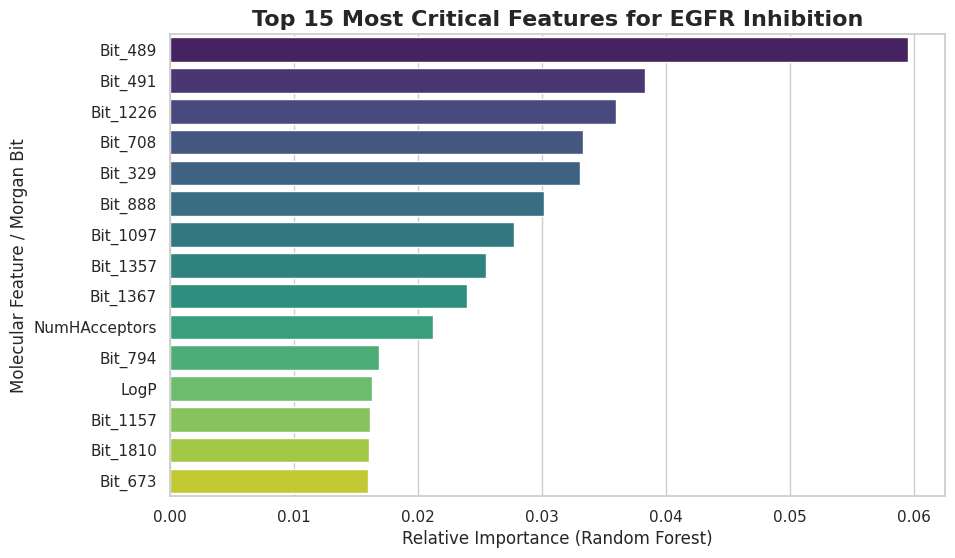

✅ Feature importance plot saved to: /content/drive/MyDrive/AI_Anticancer_Project/figures/feature_importance.png


In [6]:
# ==============================
# 17. Feature Importance Analysis
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Extracting AI decision logic...")

# 1. Get the names of the features that survived the variance filter
original_feature_names = X_train.columns
surviving_features = original_feature_names[selector.get_support()]

# 2. Extract importance scores from the tuned Random Forest
importances = best_rf_model.feature_importances_

# 3. Create a DataFrame to easily sort and view them
feature_importance_df = pd.DataFrame({
    'Feature': surviving_features,
    'Importance': importances
})

# Sort by most important (top 15)
top_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

# ==============================
# 18. Plotting for Publication
# ==============================
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')

plt.title('Top 15 Most Critical Features for EGFR Inhibition', fontsize=16, fontweight='bold')
plt.xlabel('Relative Importance (Random Forest)', fontsize=12)
plt.ylabel('Molecular Feature / Morgan Bit', fontsize=12)

# Save the figure to your Drive for your portfolio/README
figure_path = '/content/drive/MyDrive/AI_Anticancer_Project/figures/feature_importance.png'
import os
os.makedirs('/content/drive/MyDrive/AI_Anticancer_Project/figures/', exist_ok=True)
plt.savefig(figure_path, dpi=300, bbox_inches='tight')

plt.show()
print(f"✅ Feature importance plot saved to: {figure_path}")

Generating chemical structure for Morgan Bit 489...


[02:34:30] DEPRECATION WARNING: please use MorganGenerator


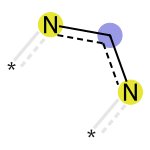

✅ Fragment image saved to Drive: /content/drive/MyDrive/AI_Anticancer_Project/figures/bit_489_fragment.png


In [7]:
# ==============================
# 19. Visualizing the Top Structural Feature
# ==============================
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from IPython.display import display

# We know from the chart that Bit_489 is the most critical feature
top_bit = 489

# Find all molecules in our dataset where the AI saw this specific fragment
mols_with_bit = X_new[X_new[f'Bit_{top_bit}'] == 1].index

if len(mols_with_bit) > 0:
    # Grab the first molecule from that list
    example_idx = mols_with_bit[0]
    example_smiles = final_df.loc[example_idx, 'SMILES']
    example_mol = Chem.MolFromSmiles(example_smiles)

    # Regenerate the fingerprint for this molecule, but this time ask RDKit to
    # remember the exact atoms that correspond to each bit (using a dictionary)
    bit_info = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(example_mol, radius=2, nBits=2048, bitInfo=bit_info)

    # Draw the specific chemical fragment that corresponds to Bit 489
    if top_bit in bit_info:
        print(f"Generating chemical structure for Morgan Bit {top_bit}...")
        img = Draw.DrawMorganBit(example_mol, top_bit, bit_info)

        # Save the image for your portfolio
        img_path = '/content/drive/MyDrive/AI_Anticancer_Project/figures/bit_489_fragment.png'
        img.save(img_path)

        display(img)
        print(f"✅ Fragment image saved to Drive: {img_path}")
    else:
        print("Bit not found in this specific molecule's mapping.")
else:
    print(f"No molecules found containing Bit {top_bit}.")

What is Bit 489? (The Chemistry)
The image generated shows a nitrogen atom connected to a carbon, which is connected to another nitrogen atom (N-C-N), with dashed lines indicating an aromatic (ring) system.

In medicinal chemistry, this specific fragment is the hallmark of a Pyrimidine or Quinazoline ring.

Why does this matter? Because almost all FDA-approved EGFR inhibitors (like Gefitinib, Erlotinib, and Afatinib) are built around a quinazoline core!

The AI figured out on its own that this specific nitrogen arrangement is critical for the drug to anchor itself via hydrogen bonds into the "hinge region" of the EGFR protein's ATP-binding pocket.

Phase 6: The Final Test (Virtual Screening)
This is the grand finale. We have a trained, tuned, and chemically logical AI. Now, we are going to act like a real pharmaceutical company. We are going to feed the AI brand new, unseen molecules and ask it: "Will this inhibit EGFR?"

We will test two molecules:

Gefitinib (Iressa): A famous, real-world FDA-approved EGFR inhibitor.

Aspirin: A common painkiller that has absolutely nothing to do with cancer or EGFR.

In [8]:
# ==============================
# 20. The Virtual Screening Engine
# ==============================
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem
import joblib

print("Booting up prediction engine...")

# Load the saved model and feature selector (assuming they are still in memory or Drive)
# best_rf_model = joblib.load('/content/drive/MyDrive/AI_Anticancer_Project/models/rf_tuned_model.pkl')
# selector = joblib.load('/content/drive/MyDrive/AI_Anticancer_Project/models/feature_selector.pkl')

def predict_anticancer_activity(smiles, model, feature_selector):
    """Takes a SMILES string, processes it, and predicts EGFR inhibition."""

    # 1. Check if molecule is valid
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return "Invalid SMILES"

    # 2. Calculate bulk descriptors
    desc = {
        'MolWt': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'NumHDonors': Descriptors.NumHDonors(mol),
        'NumHAcceptors': Descriptors.NumHAcceptors(mol)
    }

    # 3. Calculate Morgan Fingerprints (2048 bits)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    fp_array = np.array(fp)

    # 4. Combine into a single row DataFrame
    # Note: Column names must perfectly match how the model was trained
    feature_dict = desc.copy()
    for i in range(2048):
        feature_dict[f'Bit_{i}'] = fp_array[i]

    df_pred = pd.DataFrame([feature_dict])

    # 5. Apply the variance filter (drop the noisy columns exactly like training)
    X_clean = feature_selector.transform(df_pred)

    # 6. Make Prediction
    predicted_pIC50 = model.predict(X_clean)[0]

    # 7. Convert pIC50 back to IC50 (nM) for human readability
    # pIC50 = -log10(IC50_M) -> IC50_M = 10^(-pIC50)
    ic50_molar = 10 ** (-predicted_pIC50)
    ic50_nm = ic50_molar * 1e9

    return predicted_pIC50, ic50_nm

# ==============================
# 21. Run the Test!
# ==============================

# Test 1: Gefitinib (A real EGFR Inhibitor)
gefitinib_smiles = 'COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN'

# Test 2: Aspirin (A common painkiller)
aspirin_smiles = 'CC(=O)Oc1ccccc1C(=O)O'

print("\n--- VIRTUAL SCREENING RESULTS ---")

gef_pic50, gef_ic50 = predict_anticancer_activity(gefitinib_smiles, best_rf_model, selector)
print(f"Gefitinib (Cancer Drug) -> Predicted pIC50: {gef_pic50:.2f} | Estimated IC50: {gef_ic50:.2f} nM")

asp_pic50, asp_ic50 = predict_anticancer_activity(aspirin_smiles, best_rf_model, selector)
print(f"Aspirin (Painkiller)    -> Predicted pIC50: {asp_pic50:.2f} | Estimated IC50: {asp_ic50:.2f} nM")
print("---------------------------------")
print("Note: Lower IC50 (nM) means STRONGER drug activity.")

Booting up prediction engine...

--- VIRTUAL SCREENING RESULTS ---


[02:39:17] DEPRECATION WARNING: please use MorganGenerator


Gefitinib (Cancer Drug) -> Predicted pIC50: 7.54 | Estimated IC50: 29.02 nM
Aspirin (Painkiller)    -> Predicted pIC50: 4.28 | Estimated IC50: 52272.39 nM
---------------------------------
Note: Lower IC50 (nM) means STRONGER drug activity.


[02:39:18] DEPRECATION WARNING: please use MorganGenerator


Saving the data so far.

In [9]:
# ==========================================
# AI Anticancer Drug Discovery Pipeline
# ==========================================

import pandas as pd
import numpy as np
import joblib
import os
from chembl_webresource_client.new_client import new_client
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.feature_selection import VarianceThreshold

def main():
    print("1. Setting up directories...")
    os.makedirs('data', exist_ok=True)
    os.makedirs('models', exist_ok=True)

    print("2. Fetching EGFR data from ChEMBL...")
    target = new_client.target
    target_id = target.search('EGFR')[0]['target_chembl_id']
    activity = new_client.activity.filter(target_chembl_id=target_id, standard_type="IC50")
    df = pd.DataFrame.from_dict(activity)[['canonical_smiles', 'standard_value', 'standard_units']].dropna()
    df.columns = ['SMILES', 'IC50', 'Units']

    print("3. Cleaning and Transforming Data...")
    df['IC50'] = df['IC50'].astype(float)
    df = df[(df['IC50'] > 0) & (df['Units'].isin(['nM', 'uM', 'mM', 'µM']))]

    def to_nm(row):
        return row['IC50'] * 1000 if row['Units'] in ['uM', 'µM'] else (row['IC50'] * 1e6 if row['Units'] == 'mM' else row['IC50'])

    df['IC50_nM'] = df.apply(to_nm, axis=1)
    df['pIC50'] = -np.log10(df['IC50_nM'] * 1e-9)
    df = df[['SMILES', 'pIC50']].dropna().reset_index(drop=True)

    print("4. Calculating RDKit & Morgan Features...")
    features = []
    for smiles in df['SMILES']:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            desc = [Descriptors.MolWt(mol), Descriptors.MolLogP(mol),
                    Descriptors.NumHDonors(mol), Descriptors.NumHAcceptors(mol)]
            fp = list(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048))
            features.append(desc + fp)
        else:
            features.append([np.nan]*2052)

    cols = ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors'] + [f'Bit_{i}' for i in range(2048)]
    feat_df = pd.DataFrame(features, columns=cols)
    final_df = pd.concat([df, feat_df], axis=1).dropna()

    final_df.to_csv('data/final_ml_dataset.csv', index=False)

    print("5. Training & Tuning the AI Model...")
    X = final_df.drop(columns=['SMILES', 'pIC50'])
    y = final_df['pIC50']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Filter out empty/noisy fingerprint bits
    selector = VarianceThreshold(threshold=0.01)
    X_train_clean = selector.fit_transform(X_train)

    # Fast hyperparameter tune
    rf = RandomForestRegressor(random_state=42, n_jobs=-1)
    params = {'n_estimators': [100, 200], 'max_depth': [None, 20], 'min_samples_split': [2, 5]}
    search = RandomizedSearchCV(rf, params, n_iter=5, cv=3, random_state=42, n_jobs=-1)
    search.fit(X_train_clean, y_train)

    best_model = search.best_estimator_

    print("6. Saving final artifacts...")
    joblib.dump(best_model, 'models/rf_tuned_model.pkl')
    joblib.dump(selector, 'models/feature_selector.pkl')

    print("✅ Pipeline Complete! Dataset and Models saved locally.")

if __name__ == "__main__":
    main()

1. Setting up directories...
2. Fetching EGFR data from ChEMBL...
3. Cleaning and Transforming Data...
4. Calculating RDKit & Morgan Features...


[02:44:18] DEPRECATION WARNING: please use MorganGenerator
[02:44:18] DEPRECATION WARNING: please use MorganGenerator
[02:44:18] DEPRECATION WARNING: please use MorganGenerator
[02:44:18] DEPRECATION WARNING: please use MorganGenerator
[02:44:18] DEPRECATION WARNING: please use MorganGenerator
[02:44:18] DEPRECATION WARNING: please use MorganGenerator
[02:44:18] DEPRECATION WARNING: please use MorganGenerator
[02:44:18] DEPRECATION WARNING: please use MorganGenerator
[02:44:18] DEPRECATION WARNING: please use MorganGenerator
[02:44:18] DEPRECATION WARNING: please use MorganGenerator
[02:44:18] DEPRECATION WARNING: please use MorganGenerator
[02:44:18] DEPRECATION WARNING: please use MorganGenerator
[02:44:18] DEPRECATION WARNING: please use MorganGenerator
[02:44:18] DEPRECATION WARNING: please use MorganGenerator
[02:44:18] DEPRECATION WARNING: please use MorganGenerator
[02:44:18] DEPRECATION WARNING: please use MorganGenerator
[02:44:18] DEPRECATION WARNING: please use MorganGenerat

5. Training & Tuning the AI Model...
6. Saving final artifacts...
✅ Pipeline Complete! Dataset and Models saved locally.
